# German Credit Risk — Bias Detection & Mitigation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from fairlearn.metrics import (
    MetricFrame, selection_rate,
    demographic_parity_difference,
    equalized_odds_difference,
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.postprocessing import ThresholdOptimizer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
DATA_PATH = "german_credit_risk.csv"

## 1. Load Dataset

In [2]:
df_raw = pd.read_csv(DATA_PATH, index_col=0)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


## 2. Data Validation & Preprocessing

In [3]:
df = df_raw.copy()

# --- Basic validation ---
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (1000, 10)

Dtypes:
 Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

Missing values:
 Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Duplicates: 0


In [4]:
# --- Fill missing categoricals with mode ---
for col in ['Saving accounts', 'Checking account']:
    df[col] = df[col].fillna(df[col].mode()[0])

# --- Binary target: good=0, bad=1 ---
df['Risk'] = (df['Risk'] == 'bad').astype(int)

# --- Age group for bias analysis ---
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 45, 100],
                        labels=['Young(<30)', 'Middle(30-45)', 'Senior(45+)'])

print("Risk distribution:\n", df['Risk'].value_counts())
print("\nSex distribution:\n", df['Sex'].value_counts())
print("\nAge group distribution:\n", df['AgeGroup'].value_counts())

Risk distribution:
 Risk
0    700
1    300
Name: count, dtype: int64

Sex distribution:
 Sex
male      690
female    310
Name: count, dtype: int64

Age group distribution:
 AgeGroup
Young(<30)       411
Middle(30-45)    403
Senior(45+)      186
Name: count, dtype: int64


## 3. EDA + Visualization

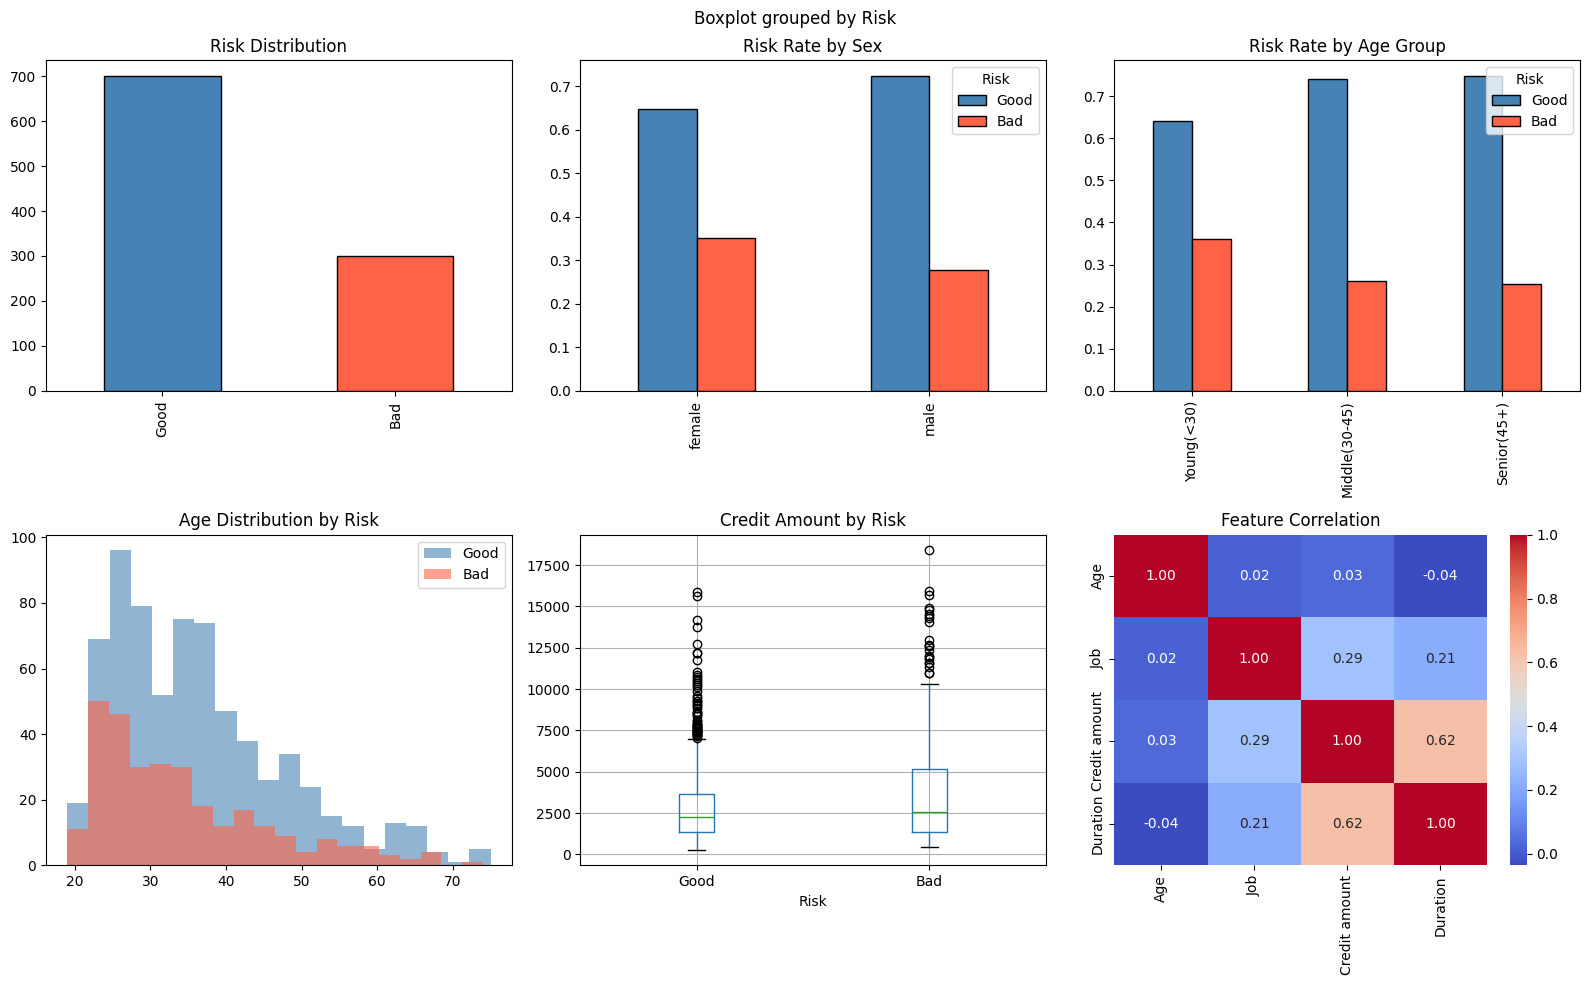

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('German Credit Risk — EDA', fontsize=15, fontweight='bold')

# 1. Risk distribution
df['Risk'].value_counts().rename({0: 'Good', 1: 'Bad'}).plot(
    kind='bar', ax=axes[0,0], color=['steelblue','tomato'], edgecolor='black')
axes[0,0].set_title('Risk Distribution'); axes[0,0].set_xlabel('')

# 2. Sex vs Risk
pd.crosstab(df['Sex'], df['Risk'], normalize='index').rename(columns={0:'Good',1:'Bad'}).plot(
    kind='bar', ax=axes[0,1], color=['steelblue','tomato'], edgecolor='black')
axes[0,1].set_title('Risk Rate by Sex'); axes[0,1].set_xlabel('')

# 3. Age group vs Risk
pd.crosstab(df['AgeGroup'], df['Risk'], normalize='index').rename(columns={0:'Good',1:'Bad'}).plot(
    kind='bar', ax=axes[0,2], color=['steelblue','tomato'], edgecolor='black')
axes[0,2].set_title('Risk Rate by Age Group'); axes[0,2].set_xlabel('')

# 4. Age distribution
axes[1,0].hist(df[df['Risk']==0]['Age'], alpha=0.6, bins=20, color='steelblue', label='Good')
axes[1,0].hist(df[df['Risk']==1]['Age'], alpha=0.6, bins=20, color='tomato', label='Bad')
axes[1,0].set_title('Age Distribution by Risk'); axes[1,0].legend()

# 5. Credit amount vs Risk
df.boxplot(column='Credit amount', by='Risk', ax=axes[1,1])
axes[1,1].set_title('Credit Amount by Risk')
plt.sca(axes[1,1]); plt.xticks([1,2], ['Good','Bad'])

# 6. Correlation heatmap (numeric)
num_df = df.select_dtypes(include='number').drop(columns=['Risk'])
sns.heatmap(num_df.corr(), ax=axes[1,2], annot=True, fmt='.2f', cmap='coolwarm')
axes[1,2].set_title('Feature Correlation')

plt.tight_layout()
plt.show()

## 4. Bias Detection

### 4a. Data-Level Bias

In [6]:
def dataset_bias_scan(df, target_col, sensitive_cols, dpd_threshold=0.1, di_threshold=0.8):
    results = {}
    for col in sensitive_cols:
        grouped = df.groupby(col)[target_col].mean()
        max_r, min_r = grouped.max(), grouped.min()
        dpd = float(max_r - min_r)
        di  = float(min_r / max_r) if max_r > 0 else np.nan
        results[col] = {
            'positive_rates': grouped.to_dict(),
            'DPD': round(dpd, 4),
            'DI': round(di, 4),
            'potential_bias': (dpd >= dpd_threshold) or (di < di_threshold),
        }
    return results

bias_results = dataset_bias_scan(df, 'Risk', ['Sex', 'AgeGroup'])
for col, m in bias_results.items():
    print(f"\n[{col}]")
    print("  Bad-loan rates:", m['positive_rates'])
    print("  DPD:", m['DPD'], "| DI:", m['DI'], "| Bias detected:", m['potential_bias'])


[Sex]
  Bad-loan rates: {'female': 0.35161290322580646, 'male': 0.2768115942028985}
  DPD: 0.0748 | DI: 0.7873 | Bias detected: True

[AgeGroup]
  Bad-loan rates: {'Young(<30)': 0.36009732360097324, 'Middle(30-45)': 0.26054590570719605, 'Senior(45+)': 0.25268817204301075}
  DPD: 0.1074 | DI: 0.7017 | Bias detected: True


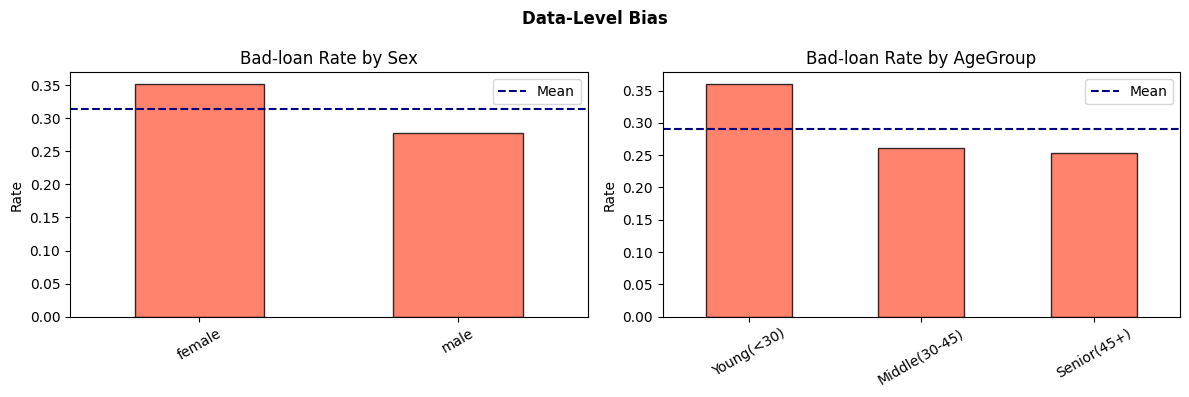

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Data-Level Bias', fontweight='bold')

for ax, col in zip(axes, ['Sex', 'AgeGroup']):
    rates = pd.Series(bias_results[col]['positive_rates'])
    rates.plot(kind='bar', ax=ax, color='tomato', edgecolor='black', alpha=0.8)
    ax.set_title(f'Bad-loan Rate by {col}')
    ax.set_ylabel('Rate'); ax.set_xlabel('')
    ax.axhline(rates.mean(), color='navy', linestyle='--', label='Mean')
    ax.legend(); ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 4b. Feature Engineering & Preprocessing Pipeline

In [8]:
TARGET       = 'Risk'
SENSITIVE_SEX = 'Sex'
DROP_COLS    = ['AgeGroup']

# Keep raw features — NO manual get_dummies
X = df.drop(columns=DROP_COLS + [TARGET, SENSITIVE_SEX])
y = df[TARGET]
sensitive = df[SENSITIVE_SEX]

CAT_COLS = X.select_dtypes(include='object').columns.tolist()
NUM_COLS = X.select_dtypes(include='number').columns.tolist()
print("Numeric :", NUM_COLS)
print("Categorical:", CAT_COLS)

# Preprocessor: scale numerics, OHE categoricals
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
])

X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# Pre-fit transform for SMOTE / fairlearn (they need numpy arrays)
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)
X_all_enc   = preprocessor.transform(X)

# Save feature schema for toolkit compatibility
feature_schema = {
    'numeric_cols': NUM_COLS,
    'categorical_cols': CAT_COLS,
    'sensitive_col': SENSITIVE_SEX,
    'target_col': TARGET,
    'drop_cols': DROP_COLS,
}
joblib.dump(feature_schema, 'feature_schema.pkl')
joblib.dump(preprocessor,   'preprocessor.pkl')
print("\nTrain encoded:", X_train_enc.shape, "| Test encoded:", X_test_enc.shape)
print("Saved: feature_schema.pkl, preprocessor.pkl")

Numeric : ['Age', 'Job', 'Credit amount', 'Duration']
Categorical: ['Housing', 'Saving accounts', 'Checking account', 'Purpose']

Train encoded: (700, 22) | Test encoded: (300, 22)
Saved: feature_schema.pkl, preprocessor.pkl


### 4c. Prediction-Level Bias (Baseline Models)

## 5. Baseline Models

In [9]:
def evaluate_model(name, model, X_t, y_t, s_t, is_threshold=False):
    y_pred = model.predict(X_t, sensitive_features=s_t) if is_threshold else model.predict(X_t)
    acc = accuracy_score(y_t, y_pred)
    mf = MetricFrame(
        metrics={'accuracy': accuracy_score, 'selection_rate': selection_rate},
        y_true=y_t, y_pred=y_pred, sensitive_features=s_t
    )
    dpd = demographic_parity_difference(y_t, y_pred, sensitive_features=s_t)
    eod = equalized_odds_difference(y_t, y_pred, sensitive_features=s_t)
    print(f"\n=== {name} ===")
    print(mf.by_group)
    print(f"Overall Accuracy : {acc:.4f}")
    print(f"DPD              : {dpd:.4f}")
    print(f"EOD              : {eod:.4f}")
    print("-" * 50)
    return {'name': name, 'accuracy': acc, 'DPD': abs(dpd), 'EOD': abs(eod)}

In [10]:
results = []

# Logistic Regression Pipeline
lr_pipe = Pipeline([('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
lr_pipe.fit(X_train_enc, y_train)
results.append(evaluate_model('Baseline — Logistic Regression', lr_pipe, X_test_enc, y_test, s_test))

# Random Forest Pipeline
rf_pipe = Pipeline([('clf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))])
rf_pipe.fit(X_train_enc, y_train)
results.append(evaluate_model('Baseline — Random Forest', rf_pipe, X_test_enc, y_test, s_test))


=== Baseline — Logistic Regression ===
        accuracy  selection_rate
Sex                             
female  0.693069        0.079208
male    0.748744        0.105528
Overall Accuracy : 0.7300
DPD              : 0.0263
EOD              : 0.0649
--------------------------------------------------

=== Baseline — Random Forest ===
        accuracy  selection_rate
Sex                             
female  0.633663        0.198020
male    0.713568        0.150754
Overall Accuracy : 0.6867
DPD              : 0.0473
EOD              : 0.0556
--------------------------------------------------


In [11]:
# Pick best baseline by accuracy
best_baseline = max(results, key=lambda x: x['accuracy'])
print("Best baseline:", best_baseline['name'])
base_estimator = rf_pipe if 'Random Forest' in best_baseline['name'] else lr_pipe

Best baseline: Baseline — Logistic Regression


## 6. Mitigation

### 6a. Reweighting (ExponentiatedGradient + DemographicParity)

In [12]:
from sklearn.base import clone

reweight_model = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    constraints=DemographicParity()
)
reweight_model.fit(X_train_enc, y_train, sensitive_features=s_train)
results.append(evaluate_model('Mitigation — Reweighting (EG)', reweight_model, X_test_enc, y_test, s_test))


=== Mitigation — Reweighting (EG) ===
        accuracy  selection_rate
Sex                             
female  0.693069        0.079208
male    0.753769        0.100503
Overall Accuracy : 0.7333
DPD              : 0.0213
EOD              : 0.0649
--------------------------------------------------


### 6b. Oversampling (SMOTE)

In [13]:
smote = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = smote.fit_resample(X_train_enc, y_train)

# Reconstruct sensitive series aligned to resampled indices
# SMOTE appends synthetic samples — replicate s_train to match length
n_orig = len(y_train)
n_resampled = len(y_res)
repeat_factor = (n_resampled // n_orig) + 1
s_res = pd.Series(
    np.tile(s_train.values, repeat_factor)[:n_resampled],
    name=s_train.name
).reset_index(drop=True)

oversample_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
oversample_model.fit(X_res, y_res)
results.append(evaluate_model('Mitigation — Oversampling (SMOTE)', oversample_model, X_test_enc, y_test, s_test))


=== Mitigation — Oversampling (SMOTE) ===
        accuracy  selection_rate
Sex                             
female  0.613861        0.514851
male    0.613065        0.371859
Overall Accuracy : 0.6133
DPD              : 0.1430
EOD              : 0.2130
--------------------------------------------------


### 6c. Threshold Optimization

In [14]:
threshold_model = ThresholdOptimizer(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    constraints='demographic_parity',
    prefit=False
)
threshold_model.fit(X_train_enc, y_train, sensitive_features=s_train)
results.append(evaluate_model('Mitigation — Threshold Optimization', threshold_model,
                               X_test_enc, y_test, s_test, is_threshold=True))


=== Mitigation — Threshold Optimization ===
        accuracy  selection_rate
Sex                             
female  0.653465        0.178218
male    0.718593        0.185930
Overall Accuracy : 0.6967
DPD              : 0.0077
EOD              : 0.0701
--------------------------------------------------


## 7. Before & After Comparison

In [15]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                               name  accuracy      DPD      EOD
     Baseline — Logistic Regression  0.730000 0.026320 0.064935
           Baseline — Random Forest  0.686667 0.047266 0.055556
      Mitigation — Reweighting (EG)  0.733333 0.021295 0.064935
  Mitigation — Oversampling (SMOTE)  0.613333 0.142992 0.212987
Mitigation — Threshold Optimization  0.696667 0.007712 0.070130


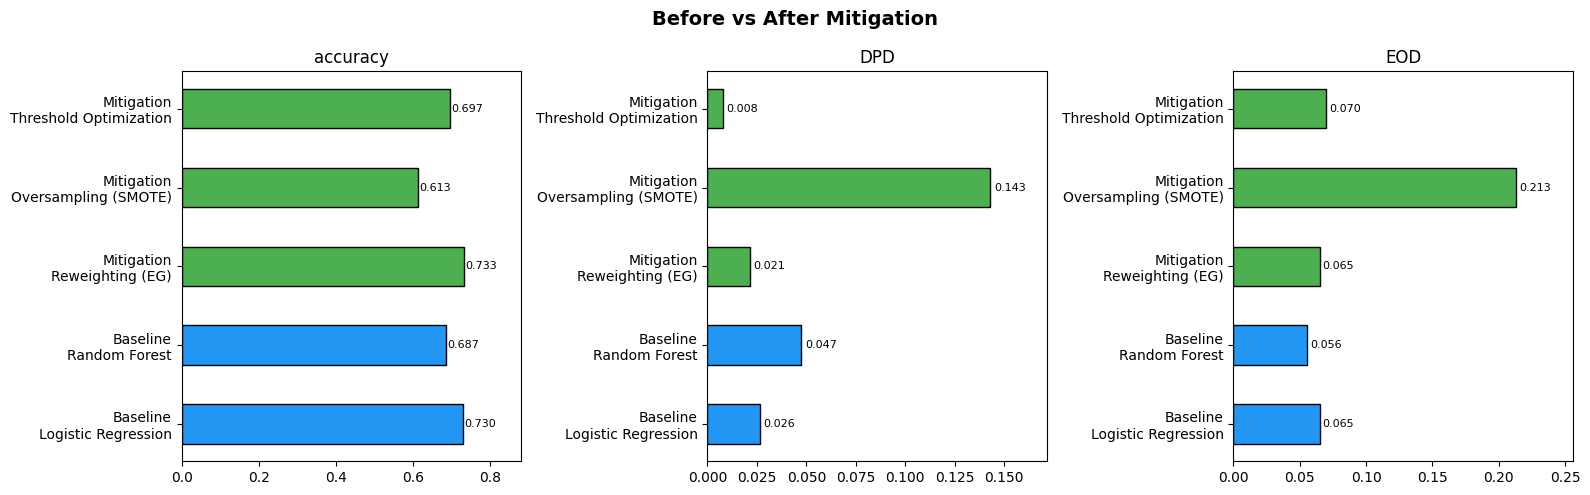


Blue = Baseline | Green = Mitigated


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Before vs After Mitigation', fontsize=14, fontweight='bold')
colors = ['#2196F3','#2196F3','#4CAF50','#4CAF50','#4CAF50']

for ax, metric in zip(axes, ['accuracy', 'DPD', 'EOD']):
    bars = ax.barh(results_df['name'].str.replace(' — ', '\n'),
                   results_df[metric], color=colors, edgecolor='black', height=0.5)
    ax.set_title(metric); ax.set_xlim(0, results_df[metric].max() * 1.2)
    for bar in bars:
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\nBlue = Baseline | Green = Mitigated")

In [17]:
# Best mitigated model = lowest DPD among mitigation rows
mit_df = results_df[results_df['name'].str.startswith('Mitigation')]
best_mit = mit_df.loc[mit_df['DPD'].idxmin()]
print("Best mitigated model:")
print(best_mit)

Best mitigated model:
name        Mitigation — Threshold Optimization
accuracy                               0.696667
DPD                                    0.007712
EOD                                     0.07013
Name: 4, dtype: object


## 8. Save De-biased Dataset & Best Model

In [18]:
# --- Save de-biased dataset (re-predict with best model & attach fair labels) ---
best_name = best_mit['name']

model_map = {
    'Mitigation — Reweighting (EG)': reweight_model,
    'Mitigation — Oversampling (SMOTE)': oversample_model,
    'Mitigation — Threshold Optimization': threshold_model,
}
best_model = model_map[best_name]

is_thresh = isinstance(best_model, ThresholdOptimizer)
all_preds = best_model.predict(X_all_enc, sensitive_features=sensitive) if is_thresh else best_model.predict(X_all_enc)

df_debiased = df.drop(columns=['AgeGroup']).copy()
df_debiased['Risk_debiased'] = all_preds
df_debiased.to_csv('german_credit_debiased.csv', index=False)
print("Saved: german_credit_debiased.csv")

Saved: german_credit_debiased.csv


In [19]:
# --- Bundle preprocessor + model into one artifact ---
# This is the KEY fix: toolkit passes raw DataFrame → pipeline handles encoding

class FairModelBundle:
    """
    Wraps preprocessor + fair model so toolkit can call:
        bundle.predict(raw_df, sensitive_features=s)
    with raw (unenoded) features.
    """
    def __init__(self, preprocessor, model, sensitive_col, is_threshold=False):
        self.preprocessor  = preprocessor
        self.model         = model
        self.sensitive_col = sensitive_col
        self.is_threshold  = is_threshold
        self.feature_schema = feature_schema

    def _encode(self, X_raw):
        # Accept DataFrame with original column names
        drop = self.feature_schema['drop_cols'] + \
               [self.feature_schema['target_col'], self.feature_schema['sensitive_col']]
        cols_to_drop = [c for c in drop if c in X_raw.columns]
        X_clean = X_raw.drop(columns=cols_to_drop, errors='ignore')
        return self.preprocessor.transform(X_clean)

    def predict(self, X_raw, sensitive_features=None):
        X_enc = self._encode(X_raw)
        if self.is_threshold and sensitive_features is not None:
            return self.model.predict(X_enc, sensitive_features=sensitive_features)
        return self.model.predict(X_enc)

    def predict_proba(self, X_raw):
        X_enc = self._encode(X_raw)
        return self.model.predict_proba(X_enc)


bundle = FairModelBundle(
    preprocessor=preprocessor,
    model=best_model,
    sensitive_col=SENSITIVE_SEX,
    is_threshold=is_thresh,
)
joblib.dump(bundle, 'best_fair_model.pkl')
print(f"Saved: best_fair_model.pkl  ({best_name})")
print("Bundle accepts raw DataFrame — no manual encoding needed.")

Saved: best_fair_model.pkl  (Mitigation — Threshold Optimization)
Bundle accepts raw DataFrame — no manual encoding needed.


In [20]:
# --- Sanity check: load bundle & predict on RAW test features ---
loaded_bundle = joblib.load('best_fair_model.pkl')

# Pass raw X_test (original DataFrame, not encoded) — this is how toolkit will call it
test_pred = loaded_bundle.predict(X_test, sensitive_features=s_test)

print("Loaded bundle accuracy :", round(accuracy_score(y_test, test_pred), 4))
print("DPD                    :", round(abs(demographic_parity_difference(y_test, test_pred, sensitive_features=s_test)), 4))
print("\nFiles saved:")
print("  best_fair_model.pkl    — FairModelBundle (preprocessor + model, accepts raw features)")
print("  preprocessor.pkl       — ColumnTransformer (standalone, if needed)")
print("  feature_schema.pkl     — column names / roles for toolkit introspection")
print("  german_credit_debiased.csv — original data + fair predictions")

Loaded bundle accuracy : 0.6867
DPD                    : 0.0127

Files saved:
  best_fair_model.pkl    — FairModelBundle (preprocessor + model, accepts raw features)
  preprocessor.pkl       — ColumnTransformer (standalone, if needed)
  feature_schema.pkl     — column names / roles for toolkit introspection
  german_credit_debiased.csv — original data + fair predictions
